# 维度的诅咒

**维度的诅咒（The Curse of Dimensionality）**

在现实世界中，我们常直觉地认为“信息越多越好”，但在机器学习中，特征维度（变量数量）的增加往往会带来灾难性的后果。

---

### 1. 什么是维度的诅咒？

维度的诅咒是指当特征空间的维度增加时，空间体积指数级增长，导致数据变得极其稀疏。

* **高维空间的疏离感**：
* 在二维平面（单位正方形）中，随机选两个点，平均距离约 **0.52**。
* 在三维空间（单位立方体）中，平均距离约 **0.66**。
* 在 **100 万维** 的超立方体中，平均距离高达约 **408,250**！


* **后果**：在高维空间中，几乎所有的点都彼此远离。这意味着数据点很可能分布在空间的“边缘”或“角落”，而不是中心。

---

### 2. 为什么它会破坏模型性能？

* **过拟合风险剧增**：由于高维数据点极其稀疏，新实例很可能离任何训练实例都很远。在这种情况下，预测更像是“瞎猜”，模型会拼命拟合训练集中的微小噪声，导致严重的过拟合。
* **训练效率低下**：更多的特征意味着更多的计算开销，训练速度会大幅下降。
* **距离度量失效**：很多算法（如 KNN 或 SVM）依赖计算点与点之间的距离。但在高维空间，所有点之间的距离看起来都差不多，导致这些算法无法有效区分数据。

---

### 3. 应对策略：降维的必要性

理论上，只要增加足够多的数据，就能填补高维空间的空隙。但问题是，要达到与低维空间相同的密度，所需的数据量会随维度呈 **指数级增长**。

因此，需要降维技术来：

1. **加速训练**：减少特征数，直接提升计算效率。
2. **可视化数据**：将数据降至 2D 或 3D，帮助我们直观理解数据结构。
3. **节省空间**：压缩数据集占用的磁盘和内存空间。

---

### 降维的两条主要路径

主要有两种方法：

* **投影 (Projection)**：就像把 3D 的茶杯阴影投射到 2D 墙面上。
* **流形学习 (Manifold Learning)**：就像把卷起来的纸张铺平。


## 投影

**投影（Projection）** 是最直观也最常用的技术。它的核心逻辑是将高维空间中的数据点“映射”到一个低维的子空间（如平面或直线）上。

---

### 1. 投影的核心逻辑

在大多数现实世界的问题中，训练实例并不是均匀分布在所有维度上的。

* **高维中的低维结构**：许多特征往往是高度相关的（例如，一个零件的长度和宽度），这意味着数据实际上主要集中在一个高维空间内的**低维子空间**中。
* **操作方式**：找到这个子空间，并将所有数据点垂直投影到该子空间上。通过这种方式，我们可以将维度从 $d$ 维减少到 $k$ 维（$k < d$）。

---

### 2. 投影的局限性：瑞士卷问题

虽然投影法在处理许多线性分布的数据时效果极佳（如 PCA），但它在处理**扭曲或卷曲**的数据集时会彻底失效。

经典的案例就是 **瑞士卷（Swiss Roll）** 数据集：

* **结构**：数据像卷轴一样卷在一起。
* **投影的失败**：如果尝试将瑞士卷直接投影到一个平面上，卷轴的不同层会被“压扁”在一起，导致原本在卷轴上相距很远的点在投影后变得重合。
* **结论**：在这种情况下，我们需要的不是“投影”，而是将卷轴“展开”，这就是接下来要聊的**流形学习（Manifold Learning）**。

---


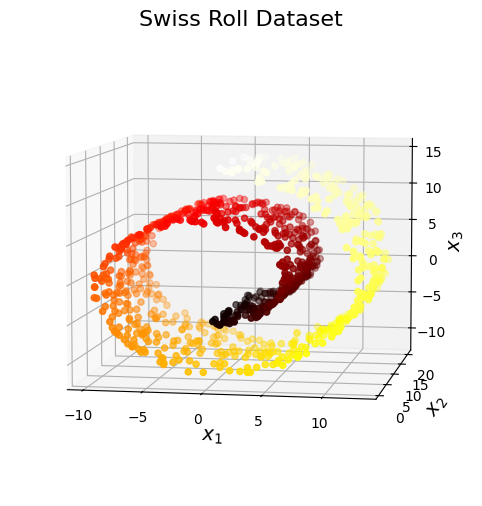

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll

# 1. 生成瑞士卷数据
# n_samples: 样本数量, noise: 噪声大小
X, t = make_swiss_roll(n_samples=1000, noise=0.1, random_state=42)

# 2. 创建 3D 图形
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3. 绘制散点图
# t 是样本在流形上的位置，用来设置颜色，使卷曲结构更清晰
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.hot)

# 4. 设置坐标轴标签和视角
ax.set_xlabel("$x_1$", fontsize=14)
ax.set_ylabel("$x_2$", fontsize=14)
ax.set_zlabel("$x_3$", fontsize=14)
ax.view_init(7, -80) # 调整视角
plt.title("Swiss Roll Dataset", fontsize=16)

plt.show()

## 流形学习

**流形学习（Manifold Learning）**。
核心假设：大多数真实世界的高维数据集，实际上都分布在一个低维的**流形**上。

---

### 1. 什么是流形（Manifold）？

简单来说，$d$ 维流形是 $n$ 维空间（$n > d$）中的一部分，它局部看起来像是一个 $d$ 维超平面。

* **直观理解**：以瑞士卷为例，它是一个位于 3D 空间中的 2D 表面。虽然它在 3D 中是弯曲的，但如果你站在卷轴表面的一点，会觉得自己是在一个 2D 平面上。
* **降维的目标**：流形学习的目标就是找到这个低维结构，并将其“展开”或“铺平”到低维空间中，同时**保留点与点之间的拓扑关系**。

---

### 2. 流形假设（Manifold Hypothesis）

流形学习通常伴随着一个关键假设：

> **如果任务（如分类或回归）在原始高维空间中很复杂，那么在流形的低维空间中表示时，它会变得更简单。**

**然而，这个假设并不总是成立。** 书中给出了一个反例：

* 有时降维后，原本清晰的决策边界反而会变得扭曲。
* **结论**：降维是否有效，完全取决于具体的数据集和任务。

---

### 3. 代表性算法

流形学习包含多种非线性降维技术：

| 算法 | 核心思想 |
| --- | --- |
| **LLE (局部线性嵌入)** | 关注局部邻居关系，通过线性重构来展开流形。 |
| **Isomap** | 通过计算测地线距离（Geodesic distance）来保持全局几何结构。 |
| **t-SNE** | 极其擅长可视化，通过概率分布保持点与点之间的相似度。 |

---

### 4. 投影 vs 流形学习：如何选择？

* **如果数据是线性的**（如投影产生的 2D 散点）：选择 **PCA** 等投影法，速度快且稳定。
* **如果数据是卷曲的/非线性的**（如瑞士卷）：选择 **流形学习**，它能提取出投影法无法识别的内在特征。

---


# PCA

降维领域最核心的概念：**主成分（Principal Components, PCs）**。

PCA 的目标是找到一系列相互正交（垂直）的轴，这些轴按顺序排列，第一个轴承载了数据中最大的方差。

---

### 1. 什么是主成分？

假设有一组高维数据：

* **第 1 个主成分 ($PC_1$)**：是数据中方差最大的那个轴。它捕捉了数据中最主要的变化方向。
* **第 2 个主成分 ($PC_2$)**：在与第一个轴垂直的所有轴中，方差第二大的那个轴。
* **第 $n$ 个主成分**：以此类推，每一个新的轴都必须与之前的轴正交，并捕捉剩余方差中的最大值。

---

### 2. 数学实现：奇异值分解 (SVD)

虽然我们可以通过特征分解来找主成分，但 Scikit-Learn 的 PCA 默认使用 **奇异值分解（Singular Value Decomposition）**。

它将矩阵 $\mathbf{X}$ 分解为三个矩阵的乘积：


$$\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T$$

* **$\mathbf{V}$ 矩阵**：包含了我们要找的所有主成分的单位向量。
* **第一列** 就是 $PC_1$，第二列就是 $PC_2$，依此类推。

> ** 注意**：在运行 PCA 之前，**必须对数据进行中心化（减去均值）**。Scikit-Learn 的 `PCA` 类会自动帮你完成这一步，但如果自己动手写 SVD，千万别忘了这一点。

---

### 3. 将数据投影到主成分上

一旦找到了主成分矩阵 $\mathbf{W}_d$（包含前 $d$ 个主成分的矩阵），将原始数据集 $\mathbf{X}$ 降维到 $d$ 维的计算非常简单：


$$\mathbf{X}_{d\text{-proj}} = \mathbf{X} \mathbf{W}_d$$

这本质上是将数据点从原始坐标系转换到了由主成分定义的新坐标系中。

---

### 4. 解释方差比 (Explained Variance Ratio)

这是评价 PCA 效果最重要的指标：**每一个主成分涵盖了整个数据集方差的百分之多少**。

* 例如：$PC_1$ 涵盖了 84%，$PC_2$ 涵盖了 10%。
* **意义**：这意味着如果只保留前两个主成分，依然保留了 94% 的原始信息，而舍弃的仅是 6% 的噪声或次要信息。

---



In [3]:
X_centered = X-X.mean(axis = 0)
U,s,V = np.linalg.svd(X_centered)
c1 = V.T[:,0]
c2 = V.T[:,1]

In [6]:
W2 = V.T[:,2]
X2D  =X_centered.dot(W2)

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

## 方差解释率

**方差解释率（Explained Variance Ratio）**：每一个主成分（Principal Component）究竟保留了原始数据中百分之多少的信息。

---

### 1. 核心定义

方差在统计学中代表了数据的“波动”或“信息量”。

* **单轴解释率**：表示某一个主成分的方差占总方差的比例。
* **累计解释率**：将前 $k$ 个主成分的解释率相加。如果前两个主成分的累计解释率是 95%，说明从高维降到 2 维后，只损失了 5% 的信息。

---

### 2. 如何选择正确的维度

与其随机选择一个维度（比如硬性规定降到 2 维），更好的做法是根据**累计方差解释率**来决定。

#### 方案 A：设定阈值

通常我们会选择能够保留 **95%** 方差的维度数量。

#### 方案 B：手肘法（Elbow Method）

通过绘制累计方差与维度的关系图，会看到一个“拐点”。

* **特征**：在达到某个维度之前，解释率快速上升；之后上升变得非常缓慢。
* **决策**：这个“肘部”位置通常就是维度的最优选择，因为它在压缩程度和信息保留之间达到了平衡。

---

### 3. PCA 用于压缩

方差解释率也直观反映了压缩效率。

* **MNIST 示例**：原始数据有 784 个特征。
* **效果**：通过 PCA，你可能会发现只需 154 个特征就能保留 95% 的方差。
* **意义**：这意味着在几乎不损失识别精度的情况下，数据集的大小被压缩到了原来的 **20%** 左右，这会极大地加速后续模型（如 SVM 或随机森林）的训练。

---


In [9]:
pca =PCA()
pca.fit(X)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum > 0.95)+1

In [10]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X)

保留 95% 方差所需的维度数量: 154


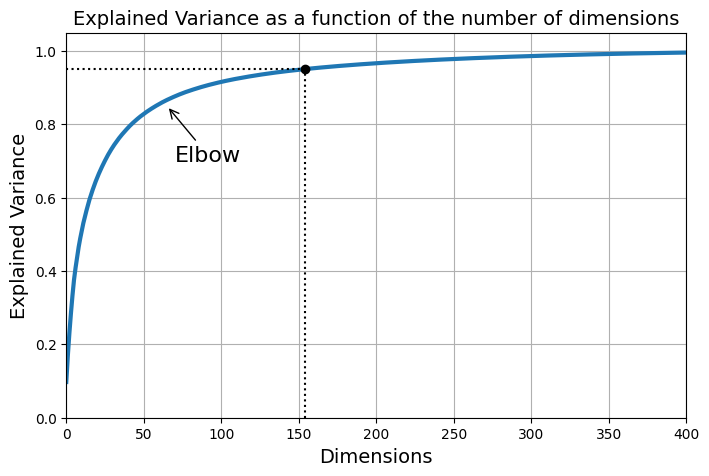

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.decomposition import PCA

# 1. 加载本地 .arff 数据集
data_arff, _ = arff.loadarff('mnist_784.arff')
# 假设前 784 列是像素数据
X = np.array([list(row)[:-1] for row in data_arff])

# 2. 训练 PCA
# 我们不限制 n_components，以便观察方差如何随维度增加而累计
pca = PCA()
pca.fit(X)

# 3. 计算累计方差解释率
cumsum = np.cumsum(pca.explained_variance_ratio_)

# 4. 找到保留 95% 方差所需的维度数量（即图中的拐点参考）
d = np.argmax(cumsum >= 0.95) + 1
print(f"保留 95% 方差所需的维度数量: {d}")

# 5. 绘图（复刻图 8-8）
plt.figure(figsize=(8, 5))
plt.plot(cumsum, linewidth=3)

# 设置坐标轴范围和标签
plt.axis([0, 400, 0, 1.05]) # MNIST 通常在 400 维以内就趋于平缓了
plt.xlabel("Dimensions", fontsize=14)
plt.ylabel("Explained Variance", fontsize=14)

# 绘制标注 95% 阈值的水平虚线和垂直虚线
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko") # 画出那个点

# 添加“拐点”注释
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"), fontsize=16)

plt.grid(True)
plt.title("Explained Variance as a function of the number of dimensions", fontsize=14)
plt.show()

### 代码关键点解析

* **`np.cumsum(pca.explained_variance_ratio_)`**：这是核心步骤。它计算前 $k$ 个成分所能解释的方差总和。
* **找“手肘”点**：通过 `np.argmax(cumsum >= 0.95)`，我们可以精确找到那条垂直虚线所在的位置（大约在 154 维附近）。
* **可视化意义**：这个图能直观的展示，为什么我们可以把 784 维压缩到 150 多维而几乎不损失性能。曲线在 100 维之后斜率明显变小，意味着后面 600 多个维度的“贡献”微乎其微。


## PCA压缩

**PCA 压缩（PCA Compression）** 不仅能减少数据的特征维度，还能在保留绝大部分关键信息的同时，极大减小数据集的存储体积。

---

### 1. 压缩效率：以 MNIST 为例

* **原始状态**：每个实例有 **784** 个特征（$28 \times 28$ 像素）。
* **压缩后**：通过保留 **95%** 的方差，特征数量减少到了 **154** 个左右。
* **成果**：数据集的大小变为了原始大小的 **20%** 不到，而绝大部分的差异性（即数字的特征）都被保留了下来。这种合理的压缩比可以极大地提升分类算法（如 SVM）的运行速度。

---

### 2. 解压缩与重建误差

PCA 的压缩是**有损**的，因为丢弃了一部分方差（例如那 5% 的噪声或微小细节）。

* **逆转换（Inverse Transform）**：可以使用 `inverse_transform()` 方法将降维后的数据映射回 784 维。
* **重建误差（Reconstruction Error）**：原始数据与重建数据之间的均方距离被称为重建误差。
* **视觉效果**：虽然重建后的图像会有轻微的模糊感，但数字的轮廓依然清晰，基本完好无损。

---

### 3. 数学原理：投影的逆过程

如果投影过程是 $\mathbf{X}_{d\text{-proj}} = \mathbf{X} \mathbf{W}_d$，那么逆转换的公式如下：

$$\mathbf{X}_{\text{recovered}} = \mathbf{X}_{d\text{-proj}} \mathbf{W}_d^T$$

这里 $\mathbf{W}_d$ 是包含前 $d$ 个主成分的矩阵。



---




In [14]:
from sklearn.decomposition import PCA

# 1. 压缩：保留 95% 方差
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X)

# 2. 解压缩：重建原始维度
X_recovered = pca.inverse_transform(X_reduced)

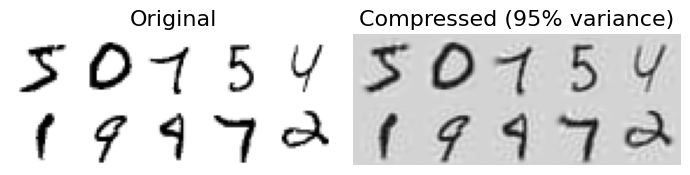

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.decomposition import PCA

# 1. 加载本地 .arff 数据集
data_arff, meta = arff.loadarff('mnist_784.arff')
X = np.array([list(row)[:-1] for row in data_arff]) # 提取特征，去掉标签列

# 2. 训练并应用 PCA（保留 95% 方差）
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X)       # 压缩：从 784 维降到约 154 维
X_recovered = pca.inverse_transform(X_reduced) # 还原：回到 784 维

# 3. 定义绘图函数
def plot_digits(instances, images_per_row=5, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary", **options)
    plt.axis("off")

# 4. 绘制对比图
plt.figure(figsize=(7, 4))

# 左侧：原始图像
plt.subplot(121)
plot_digits(X[::2100][:10], images_per_row=5) # 抽样显示 10 个数字
plt.title("Original", fontsize=16)

# 右侧：压缩并还原后的图像
plt.subplot(122)
plot_digits(X_recovered[::2100][:10], images_per_row=5)
plt.title("Compressed (95% variance)", fontsize=16)

plt.tight_layout()
plt.show()

## 增量PCA


传统的 PCA 要求将整个数据集一次性载入内存才能运行 SVD 算法。但如果处理的是规模较大的数据，内存可能会不堪重负。IPCA 的出现就是为了解决这个问题。

---

### 1. 核心原理：分块处理

IPCA 的核心思想是将原始数据集划分为多个**小批量（Mini-batches）**，并一次只向算法投喂一个批量。

* **在线学习**：它允许在不存储整个数据集的情况下逐步构建主成分。
* **内存友好**：由于每次内存中只存在一小部分数据，这使得在普通笔记本电脑上处理超大规模数据集成为可能。

---

### 2. Scikit-Learn 代码实现

可以使用 `IncrementalPCA` 类。对于本地文件，可以结合 `np.array_split` 或 Python 生成器来读取数据。

> **💡 贴士**：如果连文件都无法一次性读入内存，可以使用 NumPy 的 `memmap` 类，它允许像操作内存数组一样操作磁盘上的二进制文件，只在需要时加载数据。

---

### 3. IPCA vs. 传统 PCA

| 特性 | 传统 PCA | 增量 PCA (IPCA) |
| --- | --- | --- |
| **内存占用** | 高（需装载整个数据集） | 低（仅需装载当前批量） |
| **计算速度** | 对中小型数据较快 | 略慢（因为需要多次迭代） |
| **适用场景** | 数据量小于内存容量 | 超大数据集或在线流式数据 |

---

In [15]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X,n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.partial_fit(X)


## 随机PCA

**随机 PCA (Randomized PCA)** 是一种非常巧妙的优化算法，专门为处理“高维、海量”数据而设计。

当你不仅需要降维，且原始数据的维度和样本量都非常大时，传统的奇异值分解（SVD）会变得极其缓慢。此时，随机 PCA 就派上用场了。

---

### 1. 核心思想：近似与提速

传统的 PCA 试图精确计算出所有的奇异值，这在数学上非常诚实，但计算开销很大。

* **基本原理**：随机 PCA 使用一种随机算法来快速寻找前 $d$ 个主成分的**近似值**。
* **计算复杂度**：
* 传统 SVD：$O(m \times n^2 + n^3)$
* 随机 PCA：$O(m \times d^2 + d^3)$


* **结论**：当目标维度 $d$ 远小于原始维度 $n$ 时（例如将 784 维降到 10 维），随机 PCA 的执行速度会比传统 PCA 快好几个数量级。

---

### 2. Scikit-Learn 代码实现

在 `PCA` 类中，只需要通过 `svd_solver` 参数就能开启这个模式。



> ** 智能选择**：Scikit-Learn 的默认设置是 `svd_solver="auto"`。这意味着如果数据维度大于 500 且 $d$ 小于 $m$ 或 $n$ 的 80%，它会自动切换到随机 PCA 算法。

---

### 3. 适用场景对照

| 特性 | 传统 PCA (Full SVD) | 随机 PCA (Randomized SVD) |
| --- | --- | --- |
| **精度** | 绝对精确 | 极高近似（通常足够使用） |
| **速度** | 数据量大时非常慢 | 对超高维数据极快 |
| **内存** | 需载入完整数据 | 需载入完整数据（若需分块请用 IPCA） |
| **最佳用途** | $d$ 与 $n$ 接近时 | **$d$ 远小于 $n$ 时** |

---

### 整理笔记


到目前为止，我们已经梳理了 PCA 的分支：

1. **普通 PCA**：投影、方差保留、压缩。
2. **增量 PCA (IPCA)**：内存装不下时，分块处理。
3. **随机 PCA**：维度太高且 $d \ll n$ 时，极速近似。


In [16]:
rnd_pca = PCA(n_components=154,svd_solver="randomized")
X_reduced = rnd_pca.fit_transform(X)

# 核主成分分析

## 选择核函数和调整超参数

**核 PCA (Kernel PCA, kPCA)**，最核心的挑战就是：**面对众多的核函数（RBF, Sigmoid, Polynomial...），该如何选择最合适的那一个？又该如何调整超参数？**

由于 kPCA 是一种无监督学习算法，它没有类似于分类任务中“准确率”那样的直接衡量指标，因此我们需要一些间接的方法。

---

### 1. 方案一：结合下游任务进行网格搜索 (Grid Search)

这是最实用的方法。我们将 kPCA 作为机器学习流水线（Pipeline）的第一步，后面接一个逻辑回归、SVM 等分类器。

* **逻辑**：如果某个核函数或超参数让最后的分类效果最好，那它就是最优的。

---

### 2. 方案二：最小化重建误差 (Reconstruction Error)

* **重建原像 (Pre-image)**：kPCA 提供了一个技巧，可以训练一个监督模型来学习如何从降低后的维度映射回原始空间。
* **判断标准**：重建后的点与原始点之间的方差越小，说明核函数捕捉到的结构越准确。

---

### 3. 核函数选择的直觉建议

| 核函数 | 适用场景 | 关键超参数 |
| --- | --- | --- |
| **RBF (高斯核)** | 绝大多数非线性场景的首选，特别是数据呈“簇状”分布时。 | `gamma` ($\gamma$)：控制影响范围，越大越容易过拟合。 |
| **Polynomial (多项式核)** | 当你认为特征之间存在高阶交互（如平方或立方关系）时。 | `degree`：多项式的阶数。 |
| **Sigmoid** | 类似于神经网络的激活函数，有时能捕捉到特殊的 S 型流形。 | `gamma` 和 `coef0`。 |
| **Linear (等同于普通 PCA)** | 当数据其实是线性分布时。 | 无需调整。 |

---

### 4. 超参数微调技巧：以 RBF 的 $\gamma$ 为例

* **$\gamma$ 过大**：模型会变得非常敏感，只关注每个点极其微小的局部，导致降维后的图像非常杂乱（过拟合）。
* **$\gamma$ 过小**：模型会过于迟钝，无法识别出弯曲的流形（如瑞士卷会看起来依然是一团乱麻）。

---


In [24]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA

data_arff, _ = arff.loadarff('mnist_784.arff')

X = np.array([list(row)[:-1] for row in data_arff])
y = np.array([row[-1] for row in data_arff])
y = y.astype(np.uint8)

X_sample = X[:1000]
y_sample = y[:1000]

clf = Pipeline([
    ('kpca', KernelPCA(n_components=154)),
    ('log_reg', LogisticRegression())
])

param_grid = [{
    'kpca__gamma':np.linspace(0.03,0.05,10),
    'kpca__kernel':['rbf','sigmoid']
}]
grid_search = GridSearchCV(clf, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_sample,y_sample)

,estimator,Pipeline(step...egression())])
,param_grid,"[{'kpca__gamma': array([0.03 ..., 0.05 ]), 'kpca__kernel': ['rbf', 'sigmoid']}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,154


In [25]:
print(grid_search.best_params_)

{'kpca__gamma': np.float64(0.03), 'kpca__kernel': 'rbf'}


## 局部线性嵌入

**局部线性嵌入（Locally Linear Embedding, LLE）**。


---

### 1. LLE 的核心思想

LLE 是一种**非线性降维**技术，它不依赖于投影。

* **局部线性**：它假设每一个数据点和它的邻居在局部空间内几乎是线性的。
* **重构权重**：它首先计算每个点如何被其邻居线性重构（即找到一组权重 $w$，使得该点最接近邻居的加权和）。
* **保持流形**：最神奇的地方在于，LLE 假设这些**重构权重在降维后依然保持不变**。它会在低维空间寻找一组新坐标，使得同样的重构关系依然成立。

---

### 2. LLE 的三个步骤

1. **寻找邻居**：对每个点 $\mathbf{x}^{(i)}$，找到离它最近的 $k$ 个邻居。
2. **重构权重（最小化误差）**：计算权重矩阵 $\mathbf{W}$。
3. **降维投影**：保持 $\mathbf{W}$ 不变，映射到 $d$ 维空间，通过数学转换（特征值分解）得到低维坐标。

---

### 3. LLE 的优缺点

| 优点 | 缺点 |
| --- | --- |
| **擅长处理扭曲的流形**：能完美展开瑞士卷。 | **对噪声敏感**：如果 $k$（邻居数）选得不好，效果会很差。 |
| **无须迭代优化**：计算过程主要是线性代数运算，没有局部最小解问题。 | **样本量极大时较慢**：计算成本随样本量 $m$ 的平方增长。 |
| **参数少**：主要关注邻居数 $k$。 |  |


---

### 4. 什么时候用 LLE？

* 当确信数据分布在一个弯曲的低维流形上（如瑞士卷、S 型曲线）时。
* 当 PCA 或增量 PCA 无法有效区分不同颜色（层级）的数据点时。

---

### 总结：PCA vs. kPCA vs. LLE

* **PCA**：适合线性分布，快且稳。
* **kPCA**：通过核函数处理复杂的非线性边界，适合分类前的特征转换。
* **LLE**：通过局部邻居关系“展开”流形，适合发现数据内在的拓扑结构。


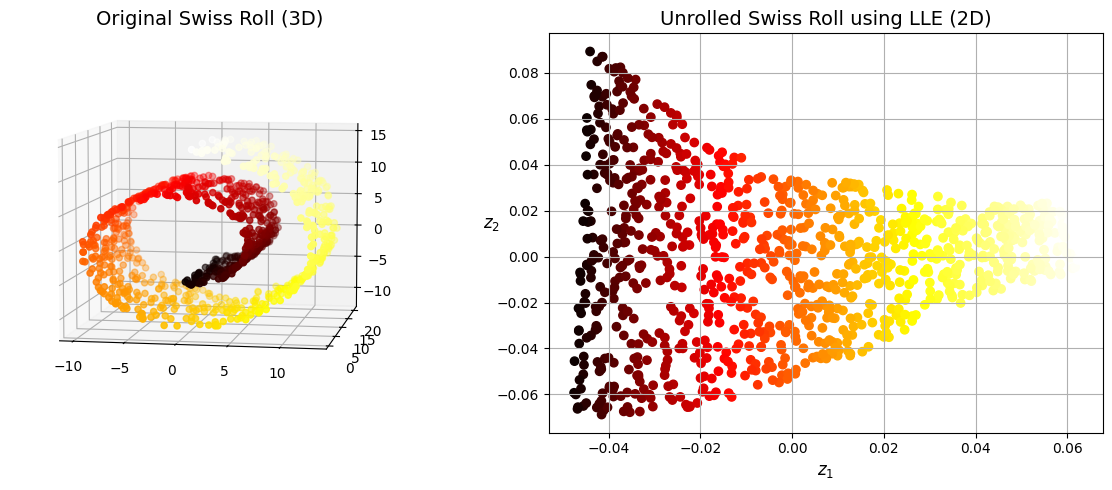

In [26]:
import matplotlib.pyplot as plt
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.datasets import make_swiss_roll

# 1. 生成瑞士卷数据
X, t = make_swiss_roll(n_samples=1000, noise=0.1, random_state=42)

# 2. 应用 LLE 算法将其降至 2 维
# n_neighbors: 邻居数量，这是 LLE 最关键的超参数
lle = LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=42)
X_reduced = lle.fit_transform(X)

# 3. 绘图对比
plt.figure(figsize=(12, 5))

# 左图：展示原始 3D 结构
ax = plt.subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.hot)
ax.set_title("Original Swiss Roll (3D)", fontsize=14)
ax.view_init(7, -80)

# 右图：展示 LLE 展开后的 2D 结构
plt.subplot(122)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=plt.cm.hot)
plt.title("Unrolled Swiss Roll using LLE (2D)", fontsize=14)
plt.xlabel("$z_1$", fontsize=12)
plt.ylabel("$z_2$", fontsize=12, rotation=0)
plt.grid(True)

plt.tight_layout()
plt.show()